# Notebook 4 — Health Recommendations Engine

**Project:** AirSense — Indoor Air Quality Monitoring & ML  
**Author:** AirSense ML Team  
**Date:** 2026-05-18

---

This notebook demonstrates the AirSense rule-based recommendations engine which:
1. Accepts real-time sensor readings (PM₂.₅, PM₁₀, CO₂, temperature, humidity)
2. Computes the EPA AQI if not pre-computed
3. Applies WHO 2021 + EPA 2024 threshold rules
4. Returns structured health, activity, and ventilation advice

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.data.loader import load_primary
from src.data.preprocessor import clean, add_aqi, add_time_features, add_lag_features, add_rolling_features, encode_labels, split
from src.recommendations.engine import recommend, batch_recommend, THRESHOLDS, AQI_LEVELS

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

print('Setup complete.')

Setup complete.


## WHO 2021 vs EPA 2024 Air Quality Standards

The recommendations engine combines both WHO and EPA thresholds, using the stricter limit where they differ.

### PM₂.₅ (24-hour average)

| Organisation | Guideline | Value (µg/m³) |
|---|---|---|
| WHO 2021 | 24-hour mean | 15 |
| WHO 2021 | Annual mean  | 5  |
| EPA 2024 | Good/Moderate boundary | 9.1 |
| EPA 2024 | Unhealthy for Sensitive Groups | 35.5 |
| EPA 2024 | Unhealthy | 55.5 |
| EPA 2024 | Very Unhealthy | 125.5 |
| EPA 2024 | Hazardous | 225.5 |

### PM₁₀ (24-hour average)

| Organisation | Guideline | Value (µg/m³) |
|---|---|---|
| WHO 2021 | 24-hour mean | 45 |
| EPA 2024 | Good/Moderate boundary | 55 |
| EPA 2024 | Unhealthy for Sensitive Groups | 155 |
| EPA 2024 | Unhealthy | 255 |

### CO₂

| Level | CO₂ (ppm) | Effect |
|---|---|---|
| Normal indoor | < 600 | No concern |
| Elevated | 600–800 | Mild cognitive effects |
| High (ASHRAE limit) | 800–1000 | Drowsiness possible |
| Very High | 1000–1500 | Headaches, fatigue |
| Dangerous | > 1500 | Immediate ventilation required |
| Critical | > 2000 | Evacuate |

### Temperature & Humidity (Comfort Zones)

| Parameter | Comfort Range | Risk Zone |
|---|---|---|
| Temperature | 18–26 °C | < 16 °C (cold) / > 32 °C (heat stress) |
| Humidity | 40–60 %RH | < 30% (dry) / > 80% (mold risk) |

## Recommendation Engine Demo — 5 Scenarios

In [2]:
scenarios = [
    {
        'name': 'Scenario 1: Good AQI (Clean indoor air)',
        'params': dict(pm25=4.0, pm10=18.0, co2=520, temperature=22.0, humidity=48.0)
    },
    {
        'name': 'Scenario 2: Moderate AQI (Urban background)',
        'params': dict(pm25=22.0, pm10=60.0, co2=750, temperature=24.0, humidity=55.0)
    },
    {
        'name': 'Scenario 3: High PM2.5 (Cooking / smoke event)',
        'params': dict(pm25=78.0, pm10=95.0, co2=900, temperature=28.0, humidity=62.0)
    },
    {
        'name': 'Scenario 4: Very High CO2 (Poor ventilation)',
        'params': dict(pm25=12.0, pm10=30.0, co2=1800, temperature=23.0, humidity=50.0)
    },
    {
        'name': 'Scenario 5: Extreme combination (Fire/Industrial event)',
        'params': dict(pm25=180.0, pm10=280.0, co2=2100, temperature=34.0, humidity=82.0)
    },
]

all_recs = []

for scenario in scenarios:
    rec = recommend(**scenario['params'])
    all_recs.append(rec)
    d = rec.to_dict()

    print('=' * 70)
    print(f"  {scenario['name']}")
    print('=' * 70)
    print(f"  Inputs  : PM2.5={scenario['params']['pm25']} µg/m³  PM10={scenario['params']['pm10']} µg/m³")
    print(f"            CO2={scenario['params']['co2']} ppm  Temp={scenario['params']['temperature']}°C  Humidity={scenario['params']['humidity']}%")
    print(f"  AQI     : {d['aqi']:.1f}  Level: {d['level']}  Color: {d['color']}")
    print()
    print('  Health advice:')
    for item in d['health_advice']:
        print(f'    - {item}')
    print('  Activity advice:')
    for item in d['activity_advice']:
        print(f'    - {item}')
    print('  Ventilation advice:')
    for item in d['ventilation_advice']:
        print(f'    - {item}')
    if d['sensor_alerts']:
        print('  ALERTS:')
        for alert in d['sensor_alerts']:
            print(f'    [!] {alert}')
    print()

  Scenario 1: Good AQI (Clean indoor air)
  Inputs  : PM2.5=4.0 µg/m³  PM10=18.0 µg/m³
            CO2=520 ppm  Temp=22.0°C  Humidity=48.0%
  AQI     : 22.2  Level: Good  Color: #00E400

  Health advice:
    - PM2.5 is within WHO 24-hour guideline (< 15 µg/m³). Air quality is acceptable.
  Activity advice:
    - All outdoor activities are safe.
  Ventilation advice:
    - Normal ventilation is sufficient.

  Scenario 2: Moderate AQI (Urban background)
  Inputs  : PM2.5=22.0 µg/m³  PM10=60.0 µg/m³
            CO2=750 ppm  Temp=24.0°C  Humidity=55.0%
  AQI     : 75.0  Level: Moderate  Color: #FFFF00

  Health advice:
    - PM2.5 (22.0 µg/m³) exceeds WHO guideline. Sensitive individuals may experience symptoms.
    - PM10 (60.0 µg/m³) exceeds WHO 24-hour guideline of 45 µg/m³.
  Activity advice:
    - Sensitive groups (asthma, heart disease, elderly, children) should reduce prolonged outdoor exertion.
  Ventilation advice:
    - Consider running air purifier with HEPA filter.

  Scenario 

In [3]:
# Compact summary table of the 5 scenarios
summary_rows = []
for scenario, rec in zip(scenarios, all_recs):
    d = rec.to_dict()
    summary_rows.append({
        'Scenario': scenario['name'].split(':')[0],
        'PM2.5': scenario['params']['pm25'],
        'PM10':  scenario['params']['pm10'],
        'CO2':   scenario['params']['co2'],
        'AQI':   round(d['aqi'], 1) if d['aqi'] is not None else 'N/A',
        'Level': d['level'],
        'Alerts': len(d['sensor_alerts']),
    })

summary_df = pd.DataFrame(summary_rows)

# Colour-code the Level column
level_colors = {
    'Good': '#00E400',
    'Moderate': '#FFFF00',
    'Unhealthy for Sensitive Groups': '#FF7E00',
    'Unhealthy': '#FF0000',
    'Very Unhealthy': '#8F3F97',
    'Hazardous': '#7E0023',
}

def style_level(val):
    color = level_colors.get(val, '#FFFFFF')
    text_color = 'white' if val in ('Unhealthy', 'Very Unhealthy', 'Hazardous') else 'black'
    return f'background-color: {color}; color: {text_color}; font-weight: bold'

summary_df.style \
    .map(style_level, subset=['Level']) \
    .set_caption('Scenario Summary — AirSense Recommendation Engine') \
    .format({'AQI': lambda x: f'{x:.1f}' if isinstance(x, float) else x})

,Scenario,PM2.5,PM10,CO2,AQI,Level,Alerts
0,Scenario 1,4.000000,18.000000,520,22.2,Good,0
1,Scenario 2,22.000000,60.000000,750,75.0,Moderate,0
2,Scenario 3,78.000000,95.000000,900,166.8,Unhealthy,1
3,Scenario 4,12.000000,30.000000,1800,56.4,Moderate,1
4,Scenario 5,180.000000,280.000000,2100,255.0,Very Unhealthy,3


## Batch Recommendations on Test Data

In [4]:
# Load and preprocess the primary dataset
try:
    df_raw = load_primary('../data/raw/Air-Quality-Dataset.csv')
except FileNotFoundError as e:
    print(f'ERROR: {e}')
    raise

df = clean(df_raw)
df = add_aqi(df)
df = add_time_features(df)
df = add_lag_features(df)
df = add_rolling_features(df)
df, _ = encode_labels(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Chronological split — take last 20% as test set
_, _, test_df = split(df, test_size=0.20, val_size=0.10)
test_tail = test_df.tail(100).copy()

print(f'Applying batch recommendations to {len(test_tail)} rows …')
batch_results = batch_recommend(test_tail)

# Build results DataFrame
batch_df = pd.DataFrame(batch_results)

# Add TIME column from test_tail for display
if 'TIME' in test_tail.columns:
    batch_df.insert(0, 'TIME', test_tail['TIME'].values)

# Expand list columns to string for display
for col in ['health_advice', 'activity_advice', 'ventilation_advice', 'sensor_alerts']:
    if col in batch_df.columns:
        batch_df[col + '_str'] = batch_df[col].apply(lambda lst: ' | '.join(lst) if lst else '-')

display_cols = ['TIME', 'aqi', 'level', 'color', 'health_advice_str', 'sensor_alerts_str'] \
    if 'TIME' in batch_df.columns \
    else ['aqi', 'level', 'color', 'health_advice_str', 'sensor_alerts_str']

print(f'Batch recommendations complete. Showing first 20 rows:')
batch_df[display_cols].head(20)

Applying batch recommendations to 100 rows …
Batch recommendations complete. Showing first 20 rows:


,TIME,aqi,level,color,health_advice_str,sensor_alerts_str
0,2023-01-22 17:15:11,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
1,2023-01-22 17:16:14,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
2,2023-01-22 17:17:17,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
3,2023-01-22 17:18:20,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
4,2023-01-22 17:19:22,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
5,2023-01-22 17:21:33,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
6,2023-01-22 17:22:36,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
7,2023-01-22 17:23:39,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
8,2023-01-22 17:24:42,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-
9,2023-01-22 17:25:44,35.555556,Good,#00E400,PM2.5 is within WHO 24-hour guideline (< 15 µg...,-


## Alert Statistics

AQI Level Distribution (last 100 test rows):
level
Good                              77
Unhealthy for Sensitive Groups    14
Moderate                           5
Unhealthy                          3
Hazardous                          1

Alert trigger statistics (n=100 rows):
  PM2.5 alerts : 0 (0%)
  PM10  alerts : 18 (18%)
  CO2   alerts : 0 (0%)
  Any alert    : 18 (18%)
  No alert     : 82 (82%)


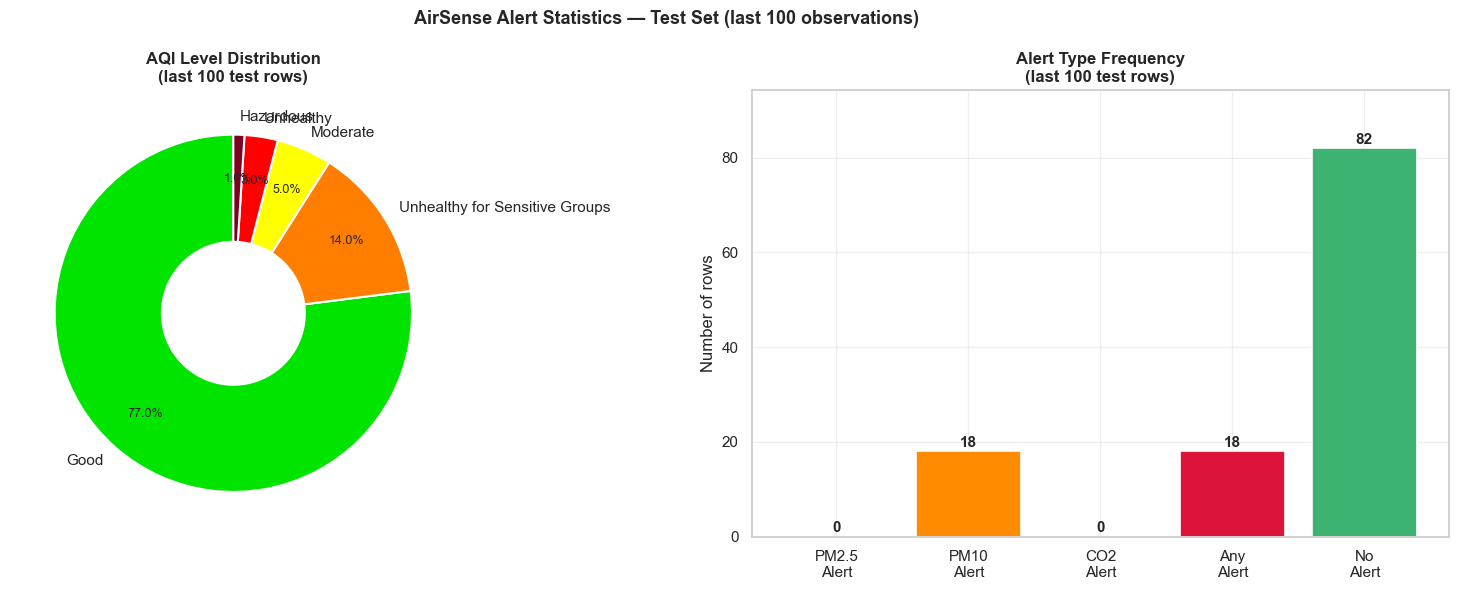

In [5]:
# Count rows per AQI level
level_counts = batch_df['level'].value_counts()
print('AQI Level Distribution (last 100 test rows):')
print(level_counts.to_string())

# Count rows that triggered each alert type
pm25_alerts  = batch_df['sensor_alerts'].apply(lambda lst: any('PM2.5' in a for a in lst)).sum()
pm10_alerts  = batch_df['sensor_alerts'].apply(lambda lst: any('PM10'  in a for a in lst)).sum()
co2_alerts   = batch_df['sensor_alerts'].apply(lambda lst: any('CO2'   in a for a in lst)).sum()
any_alerts   = batch_df['sensor_alerts'].apply(lambda lst: len(lst) > 0).sum()
no_alerts    = len(batch_df) - any_alerts

print(f'\nAlert trigger statistics (n=100 rows):')
print(f'  PM2.5 alerts : {pm25_alerts} ({pm25_alerts}%)')
print(f'  PM10  alerts : {pm10_alerts} ({pm10_alerts}%)')
print(f'  CO2   alerts : {co2_alerts} ({co2_alerts}%)')
print(f'  Any alert    : {any_alerts} ({any_alerts}%)')
print(f'  No alert     : {no_alerts} ({no_alerts}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Level distribution pie chart
ax = axes[0]
pie_colors = [level_colors.get(lv, '#AAAAAA') for lv in level_counts.index]
wedges, texts, autotexts = ax.pie(
    level_counts.values,
    labels=level_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('AQI Level Distribution\n(last 100 test rows)', fontweight='bold')

# Alert counts bar chart
ax2 = axes[1]
alert_labels = ['PM2.5\nAlert', 'PM10\nAlert', 'CO2\nAlert', 'Any\nAlert', 'No\nAlert']
alert_counts = [pm25_alerts, pm10_alerts, co2_alerts, any_alerts, no_alerts]
bar_colors   = ['tomato', 'darkorange', 'steelblue', 'crimson', 'mediumseagreen']
bars = ax2.bar(alert_labels, alert_counts, color=bar_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, alert_counts):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax2.set_ylabel('Number of rows')
ax2.set_title('Alert Type Frequency\n(last 100 test rows)', fontweight='bold')
ax2.set_ylim(0, max(alert_counts) * 1.15)

plt.suptitle('AirSense Alert Statistics — Test Set (last 100 observations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualization — AQI Timeline with Category Background Shading

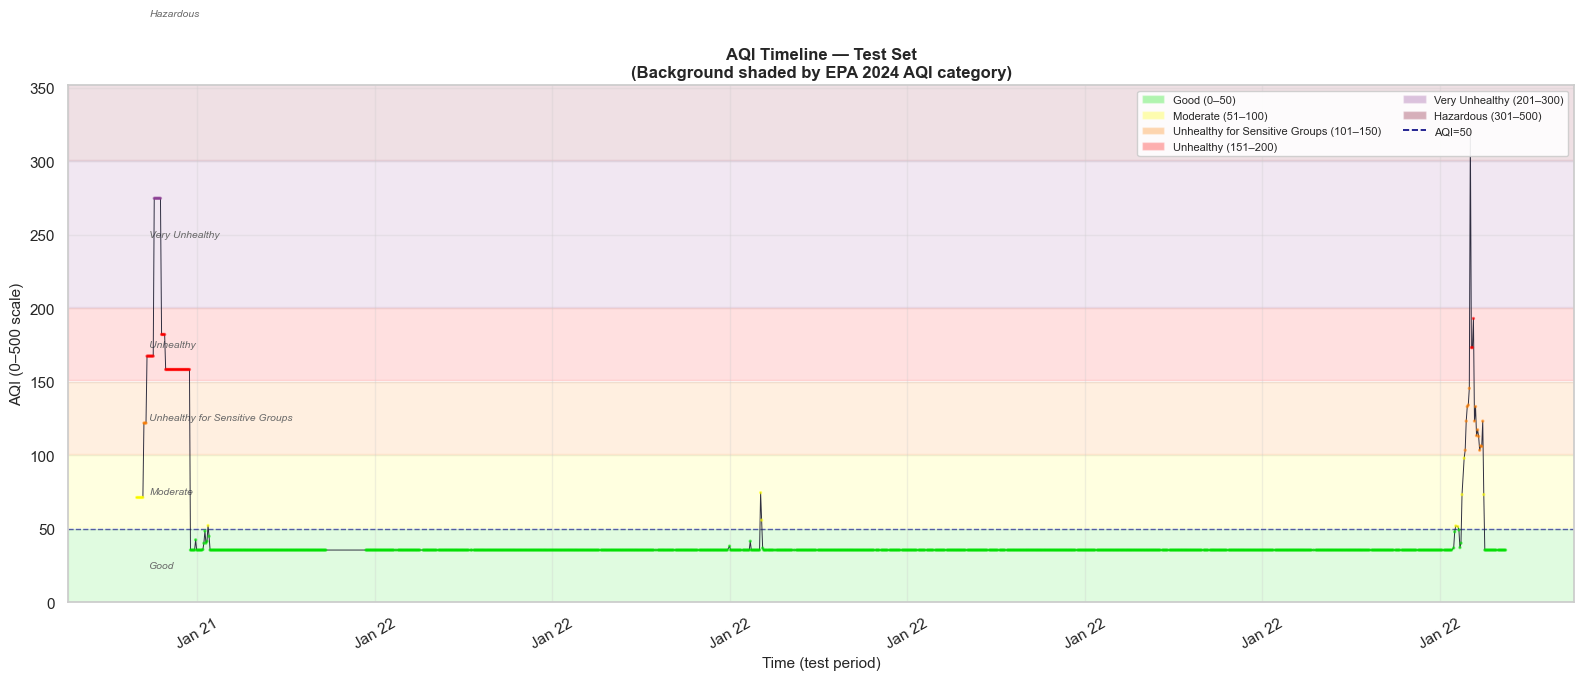

In [6]:
# Full test set AQI timeline coloured by AQI level
_, _, full_test = split(df, test_size=0.20, val_size=0.10)

time_col = 'TIME' if 'TIME' in full_test.columns else None
x_vals = full_test[time_col].values if time_col else np.arange(len(full_test))
y_vals = full_test['AQI'].values

fig, ax = plt.subplots(figsize=(16, 7))

# Background AQI category bands
for lo, hi, label, color, _ in AQI_LEVELS:
    ax.axhspan(lo, hi, alpha=0.12, color=color, zorder=0)
    ax.text(
        x_vals[int(len(x_vals) * 0.01)],
        (lo + hi) / 2,
        label,
        fontsize=7.5,
        color='dimgray',
        va='center',
        fontstyle='italic'
    )

# Plot AQI line
ax.plot(x_vals, y_vals, color='#1a1a2e', linewidth=0.7, alpha=0.9, zorder=3, label='AQI')

# Scatter-colour points by level
if 'AQI_IDX' in full_test.columns:
    aqi_idx = full_test['AQI_IDX'].values
    scatter_colors = [AQI_LEVELS[min(int(i), len(AQI_LEVELS)-1)][3] for i in aqi_idx]
    ax.scatter(x_vals, y_vals, c=scatter_colors, s=2, alpha=0.5, zorder=4)

# WHO 24h guideline
# AQI ≈ 50 corresponds to WHO threshold
ax.axhline(50, color='navy', linestyle='--', linewidth=1, alpha=0.6, label='AQI=50 (Good/Moderate boundary)')

ax.set_xlabel('Time (test period)' if time_col else 'Sample index', fontsize=11)
ax.set_ylabel('AQI (0–500 scale)', fontsize=11)
ax.set_title(
    'AQI Timeline — Test Set\n(Background shaded by EPA 2024 AQI category)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, min(y_vals.max() * 1.10, 510))

# Legend for AQI category bands
patches = [
    mpatches.Patch(facecolor=color, alpha=0.3, label=f'{label} ({lo}–{hi})')
    for lo, hi, label, color, _ in AQI_LEVELS
]
patches.append(plt.Line2D([0], [0], color='navy', linestyle='--', linewidth=1.2, label='AQI=50'))
ax.legend(handles=patches, fontsize=8, loc='upper right', ncol=2, framealpha=0.9)

if time_col:
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

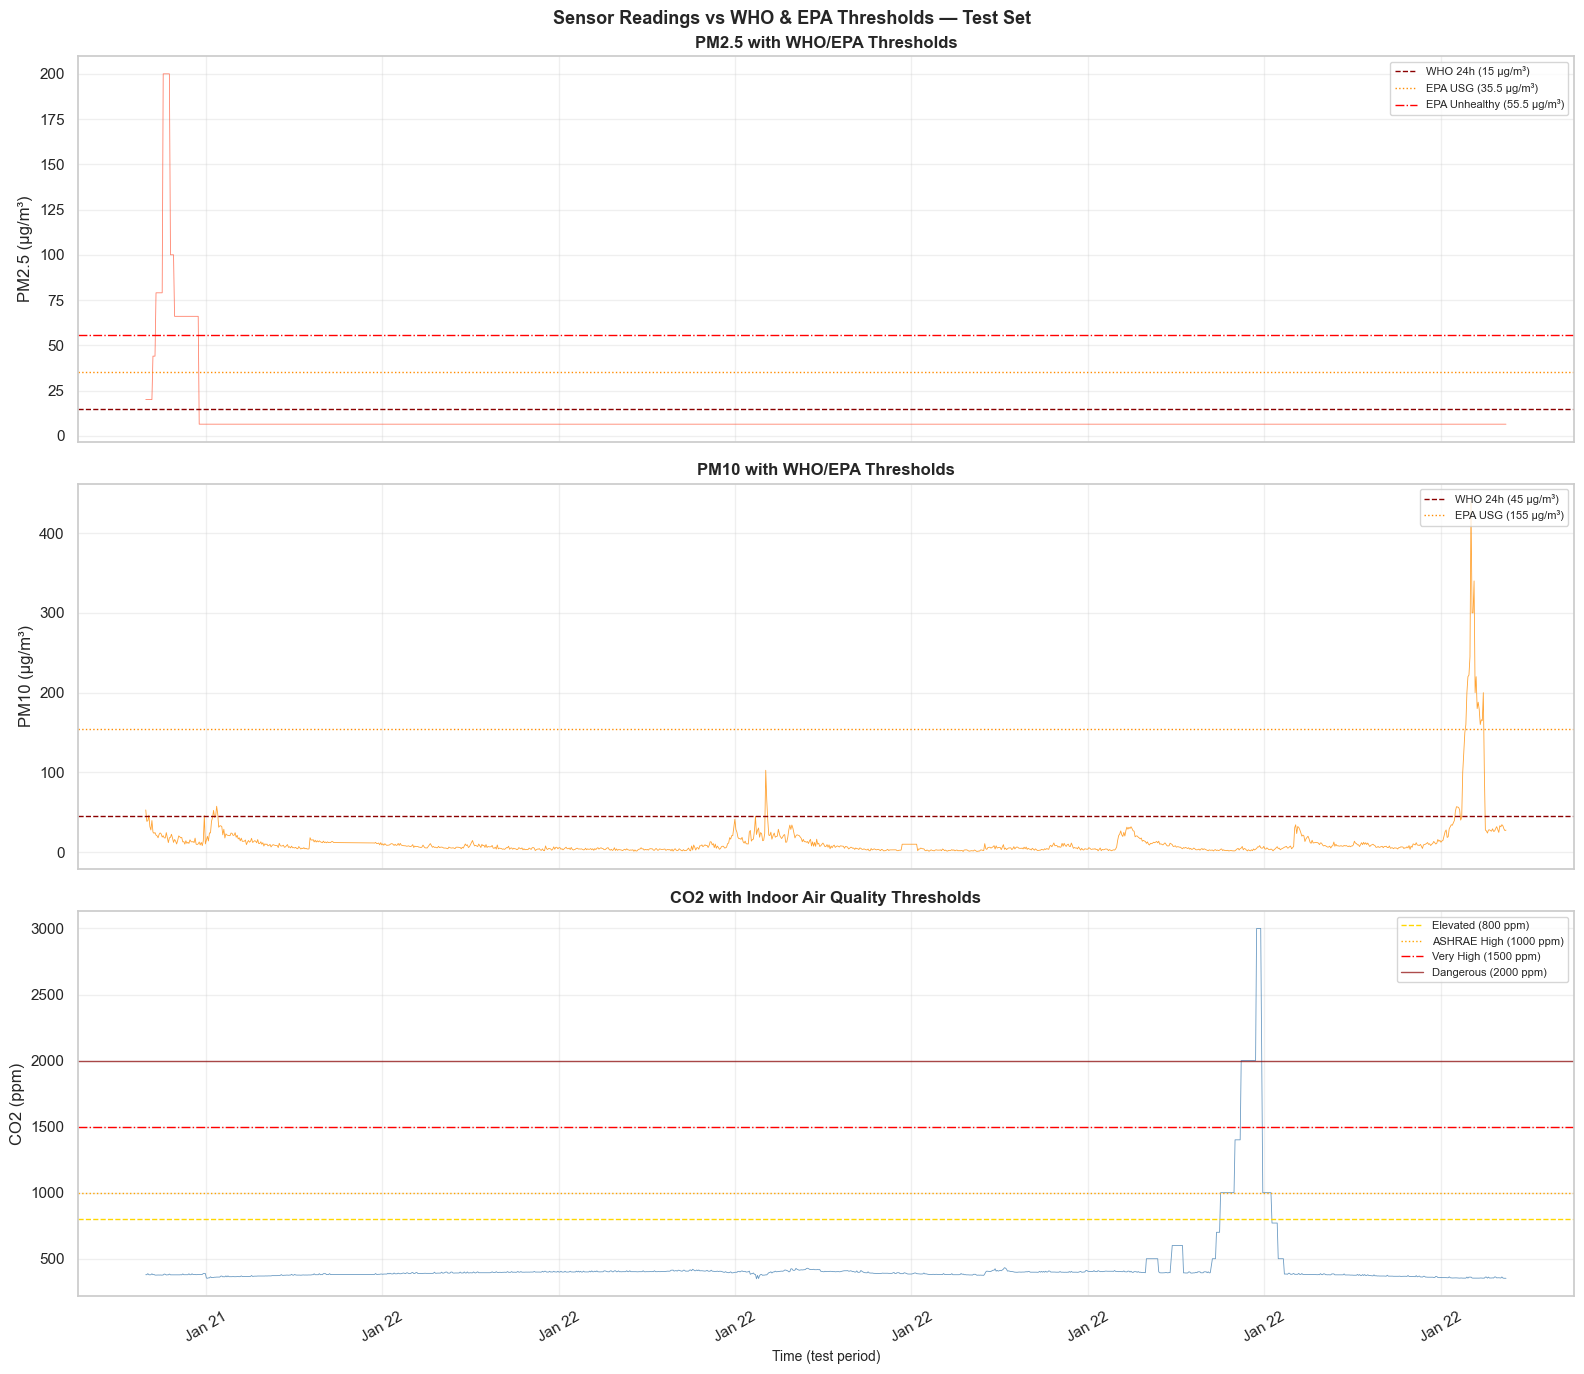

In [7]:
# Per-pollutant timeline with threshold annotations
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# PM2.5
axes[0].plot(x_vals, full_test['PM25'].values, color='tomato', linewidth=0.6, alpha=0.8)
axes[0].axhline(15.0,  color='darkred',    linestyle='--', linewidth=1, label='WHO 24h (15 µg/m³)')
axes[0].axhline(35.5,  color='darkorange', linestyle=':',  linewidth=1, label='EPA USG (35.5 µg/m³)')
axes[0].axhline(55.5,  color='red',        linestyle='-.', linewidth=1, label='EPA Unhealthy (55.5 µg/m³)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('PM2.5 with WHO/EPA Thresholds', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

# PM10
axes[1].plot(x_vals, full_test['PM10'].values, color='darkorange', linewidth=0.6, alpha=0.8)
axes[1].axhline(45.0,  color='darkred',    linestyle='--', linewidth=1, label='WHO 24h (45 µg/m³)')
axes[1].axhline(155.0, color='darkorange', linestyle=':',  linewidth=1, label='EPA USG (155 µg/m³)')
axes[1].set_ylabel('PM10 (µg/m³)')
axes[1].set_title('PM10 with WHO/EPA Thresholds', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

# CO2
axes[2].plot(x_vals, full_test['CO2'].values, color='steelblue', linewidth=0.6, alpha=0.8)
axes[2].axhline(800,  color='gold',   linestyle='--', linewidth=1, label='Elevated (800 ppm)')
axes[2].axhline(1000, color='orange', linestyle=':',  linewidth=1, label='ASHRAE High (1000 ppm)')
axes[2].axhline(1500, color='red',    linestyle='-.', linewidth=1, label='Very High (1500 ppm)')
axes[2].axhline(2000, color='darkred',linestyle='-',  linewidth=1, alpha=0.7, label='Dangerous (2000 ppm)')
axes[2].set_ylabel('CO2 (ppm)')
axes[2].set_title('CO2 with Indoor Air Quality Thresholds', fontweight='bold')
axes[2].legend(fontsize=8, loc='upper right')

if time_col:
    import matplotlib.dates as mdates
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)
axes[2].set_xlabel('Time (test period)', fontsize=10)

fig.suptitle('Sensor Readings vs WHO & EPA Thresholds — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

The AirSense recommendations engine successfully:

1. **Accepts** raw sensor readings (PM₂.₅, PM₁₀, CO₂, temperature, humidity)
2. **Computes** EPA 2024 AQI on-the-fly when not pre-provided
3. **Applies** WHO 2021 + EPA 2024 threshold rules in priority order
4. **Returns** structured `Recommendation` objects with:
   - AQI value and category (level + color hex)
   - Health advice tailored to severity
   - Activity restrictions
   - Ventilation recommendations
   - Triggered sensor alerts
5. **Scales** to batch processing via `batch_recommend()` for dashboard integration

### Integration with the ML pipeline

- The **XGBoost regression model** (Notebook 02) predicts AQI in real-time from sensor readings without needing the PM₂.₅/PM₁₀ values directly (uses all features including time and lags).
- This predicted AQI is passed to `recommend(aqi=predicted_aqi)` for immediate guidance.
- The **SARIMA / Prophet forecasters** (Notebook 03) provide 1–24 step-ahead PM₂.₅ forecasts, enabling **proactive** recommendations before thresholds are crossed.